# φ-saturation ablation

Runs the LeNet-5 + LP-M3N visual Sudoku setup in two architecture variants:

- **with_softmax** — canonical config (`sudoku_lenet5.yaml`); terminal Softmax bounds the unary potentials in $[\log(1/K), 0]$.
- **no_softmax**   — ablation variant (`sudoku_lenet5_no_softmax.yaml`); same stack with the trailing Softmax layer removed, so the unary potentials are unconstrained real-valued logits.

Everything else is identical: same data ($N=1500$ visual Sudoku), same training (LP-M3N, $\lambda = 10^{-3}$, `lr_pairwise=0.01`, `lr_phi=0.01`), same evaluation (BP at test).

## 0. Colab bootstrap (no-op locally)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys, os
    PROJECT_ROOT = '/content/drive/MyDrive/Master-thesis'
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT + '/notebooks')
    print('Colab setup done -- cwd:', os.getcwd())
except ImportError:
    print('Local run -- Colab bootstrap skipped')

Mounted at /content/drive
Colab setup done -- cwd: /content/drive/MyDrive/Master-thesis/notebooks


## 1. Setup

In [ ]:
import json
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'mnlearn').is_dir():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('could not locate project root')
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

from mnlearn.config import load_config
from mnlearn.learning import train

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TAG    = 'phi_saturation_ablation'
RESULTS    = REPO_ROOT / 'results' / RUN_TAG
THESIS_FIG = REPO_ROOT / 'thesis' / 'figures' / RUN_TAG
RESULTS.mkdir(parents=True, exist_ok=True)
THESIS_FIG.mkdir(parents=True, exist_ok=True)

CFG_WITH    = load_config(REPO_ROOT / 'configs' / 'experiments' / 'lpm3n_visual_sudoku.yaml')
CFG_WITHOUT = load_config(REPO_ROOT / 'configs' / 'experiments' / 'lpm3n_visual_sudoku_no_softmax.yaml')

# SAME (N, lambda) so the only difference is the architecture
N_TRAIN = 1500
WD      = 1e-3
SEEDS   = [0, 1, 4]

def pin(cfg):
    return replace(
        cfg,
        data=replace(cfg.data, train_size=N_TRAIN),
        training=replace(cfg.training,
                         optimizer=replace(cfg.training.optimizer, weight_decay=WD)),
    )

CFG_WITH    = pin(CFG_WITH)
CFG_WITHOUT = pin(CFG_WITHOUT)

print(f'DEVICE   = {DEVICE}')
print(f'N_TRAIN  = {N_TRAIN}, weight_decay = {WD}, seeds = {SEEDS}')

DEVICE   = cuda
N_TRAIN  = 1500, weight_decay = 0.001, seeds = [0, 1, 4]


## 2. Run both architecture variants (3 seeds each)

In [3]:
VARIANTS = [('with_softmax', CFG_WITH), ('no_softmax', CFG_WITHOUT)]

def out_dir(variant_label, seed):
    return RESULTS / f'{variant_label}_seed{seed}'

for variant_label, base_cfg in VARIANTS:
    for seed in SEEDS:
        d = out_dir(variant_label, seed)
        if (d / 'results.json').exists():
            print(f'skip: {d.name}')
            continue
        name = f'{RUN_TAG}/{d.name}'
        cfg = replace(
            base_cfg,
            experiment=replace(base_cfg.experiment, name=name, seed=seed),
        )
        print(f'running: {name}')
        train(cfg)

print('\nablation runs done.')

running: phi_saturation_ablation/with_softmax_seed0
[run] phi_saturation_ablation/with_softmax_seed0  device=cuda  output=results/phi_saturation_ablation/with_softmax_seed0
  Epoch   1:  train_loss=100.0935  hamming=0.8887  zero_one=1.0000  phi_norm=0.5331
  Epoch  10:  train_loss=13.0740  hamming=0.0575  zero_one=0.3820  phi_norm=1.3320
  Epoch  20:  train_loss=10.1010  hamming=0.0283  zero_one=0.2664  phi_norm=1.4394
  Epoch  30:  train_loss=9.0735  hamming=0.0218  zero_one=0.2382  phi_norm=1.4994
  Epoch  40:  train_loss=7.8878  hamming=0.0232  zero_one=0.2636  phi_norm=1.5435
  Epoch  50:  train_loss=7.0633  hamming=0.0172  zero_one=0.1648  phi_norm=1.5963
  Epoch  60:  train_loss=6.6532  hamming=0.0152  zero_one=0.1571  phi_norm=1.6546
  Epoch  70:  train_loss=6.4429  hamming=0.0172  zero_one=0.1607  phi_norm=1.7049
  Epoch  80:  train_loss=6.3308  hamming=0.0160  zero_one=0.1498  phi_norm=1.7359
  Epoch  90:  train_loss=6.2687  hamming=0.0169  zero_one=0.1317  phi_norm=1.7505
  E

## 3. Collect diagnostics

Pull `phi_norm`, `pairwise_diag_mean`, `pairwise_off_diag_mean`, and validation 0/1 / Hamming from each `history.json`. Final test numbers come from `results.json`.

In [4]:
def load_run(variant_label, seed):
    d = out_dir(variant_label, seed)
    hist = json.loads((d / 'history.json').read_text())
    res  = json.loads((d / 'results.json').read_text())
    return {
        'variant': variant_label,
        'seed':    seed,
        'epoch':   hist['epoch'],
        'phi_norm':        [diag['phi_norm']               for diag in hist['diagnostics']],
        'pw_diag':         [diag['pairwise_diag_mean']     for diag in hist['diagnostics']],
        'pw_off_diag':     [diag['pairwise_off_diag_mean'] for diag in hist['diagnostics']],
        'val_zero_one':    [m['zero_one'] for m in hist['val_metrics']],
        'val_hamming':     [m['hamming']  for m in hist['val_metrics']],
        'test_zero_one':   res['zero_one'],
        'test_hamming':    res['hamming'],
    }

runs = [load_run(v, s) for v, _ in VARIANTS for s in SEEDS]
print(f'{"variant":<14s} {"seed":>4s}  {"test H":>8s}  {"test 0/1":>9s}  {"final phi_norm":>15s}')
for r in runs:
    print(f'{r["variant"]:<14s} {r["seed"]:>4d}  {r["test_hamming"]:>8.4f}  {r["test_zero_one"]:>9.4f}  {r["phi_norm"][-1]:>15.4f}')

variant        seed    test H   test 0/1   final phi_norm
with_softmax      0    0.0101     0.0709           1.8204
with_softmax      1    0.0082     0.0614           1.8454
with_softmax      4    0.0067     0.0475           1.9754
no_softmax        0    0.0133     0.1439           7.8498
no_softmax        1    0.0126     0.1139           7.5046
no_softmax        4    0.0090     0.1200           7.8435


## 4. figure 


saved to /content/drive/MyDrive/Master-thesis/thesis/figures/phi_saturation_ablation


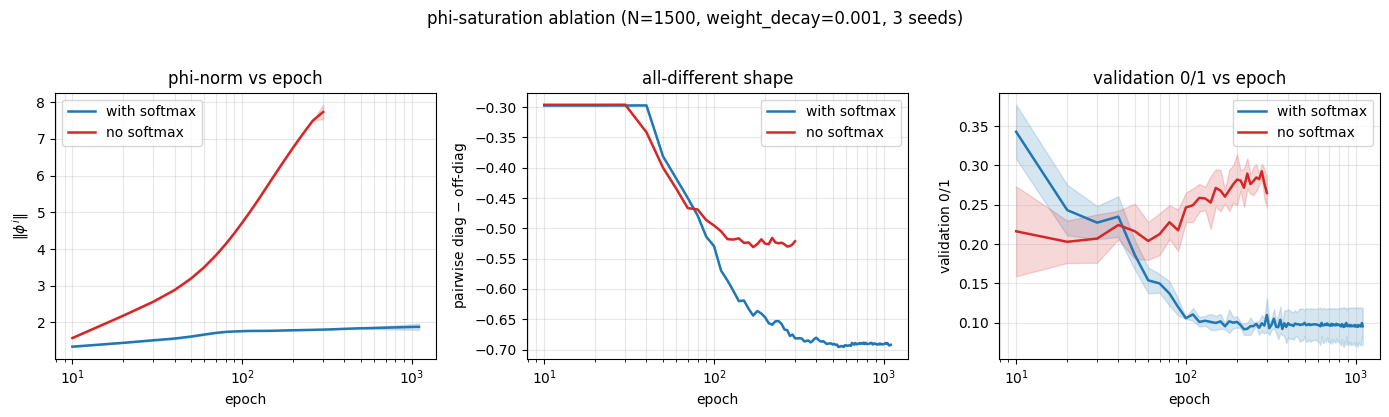

In [5]:
def aggregate(variant_label, key):
    """Forward-fill each seed at its last value, then mean ± std on a common grid."""
    seed_runs = [r for r in runs if r['variant'] == variant_label]
    max_ep    = max(max(r['epoch']) for r in seed_runs)
    grid      = np.arange(10, max_ep + 1, 10)
    curves = []
    for r in seed_runs:
        ep   = np.array(r['epoch'])
        vals = np.array(r[key])
        last = vals[-1]
        d = dict(zip(ep, vals))
        curve = []
        for e in grid:
            if e in d:
                curve.append(d[e])
            elif e > ep.max():
                curve.append(last)
            else:
                below = ep[ep <= e]
                curve.append(d[below.max()])
        curves.append(curve)
    curves = np.array(curves)
    return grid, curves.mean(0), curves.std(0, ddof=1)

COLORS = {'with_softmax': '#1f77b4', 'no_softmax': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
panels = [
    ('phi_norm',     r'$\|\phi^{i}\|$',                  'phi-norm vs epoch'),
    ('pw_gap',       'pairwise diag $-$ off-diag',          'all-different shape'),
    ('val_zero_one', 'validation $0/1$',                    'validation 0/1 vs epoch'),
]
for ax, (key, ylabel, title) in zip(axes, panels):
    for variant_label, _ in VARIANTS:
        if key == 'pw_gap':
            ep, mu_d,  _ = aggregate(variant_label, 'pw_diag')
            ep, mu_od, _ = aggregate(variant_label, 'pw_off_diag')
            mu    = mu_d - mu_od
            sigma = np.zeros_like(mu)
        else:
            ep, mu, sigma = aggregate(variant_label, key)
        ax.plot(ep, mu, label=variant_label.replace('_', ' '),
                color=COLORS[variant_label], lw=1.8)
        ax.fill_between(ep, mu - sigma, mu + sigma,
                        alpha=0.18, color=COLORS[variant_label])
    ax.set_xscale('log')
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(loc='best')

fig.suptitle(f'phi-saturation ablation (N={N_TRAIN}, weight_decay={WD}, 3 seeds)', y=1.03)
fig.tight_layout()
fig.savefig(THESIS_FIG / 'phi_saturation.png', dpi=200, bbox_inches='tight')
fig.savefig(THESIS_FIG / 'phi_saturation.pdf',         bbox_inches='tight')
print(f'saved to {THESIS_FIG}')

## 5. Final test numbers

In [6]:
def summary(variant_label):
    arr = [r for r in runs if r['variant'] == variant_label]
    H = np.array([r['test_hamming']  for r in arr])
    Z = np.array([r['test_zero_one'] for r in arr])
    return H.mean(), H.std(ddof=1), Z.mean(), Z.std(ddof=1)

print(f'{"variant":<14s}  {"H mean ± std":>20s}  {"0/1 mean ± std":>22s}')
for variant_label, _ in VARIANTS:
    h_m, h_s, z_m, z_s = summary(variant_label)
    print(f'{variant_label:<14s}  {h_m:.4f} ± {h_s:.4f}        {z_m:.4f} ± {z_s:.4f}')

variant                 H mean ± std          0/1 mean ± std
with_softmax    0.0083 ± 0.0017        0.0599 ± 0.0118
no_softmax      0.0116 ± 0.0023        0.1259 ± 0.0159
